# Visualization of embedding

This notebook serves as an example for visualisation of CPM embedding in different forms. For more details, please refer to Sections 2.4, 4.8 and 4.10 in our [paper](https://doi.org/10.1101/2025.08.22.671789).

We analyze data from [Pijuan-Sala et al. (2019)](#references), encompassing 116,312 cells from mouse embryos
at nine developmental stages between embryonic days 6.5 and 8.5. This dataset captures the transcriptional dynamics during the critical phases of gastrulation and early organ formation. The dataset was normalized to 10000 counts per cell, Log1p transformed and filtered to contain 2000 highly variable genes. The trained model and the config files for CPM can be found [here](./results/mouse_gastrulation). We directly load the embedding for this example. 

In [2]:
import sys
import os
sys.path.append(os.path.abspath(".."))
from helpers.poincare_maps import *
from model.poincare_loss import poincare_root
from helpers.visualize import plotPoincareDisc, plot_poincare_disc
import pandas as pd


data_file = "./results/mouse_gastrulation/mouse_2000vargenes.csv"
embed_file = "./results/mouse_gastrulation/mouse_2000vargenesT_2048_1_1_4096_0.15_1000_emb.csv"
root = "Epiblast"

embedding = pd.read_csv(embed_file, header=None).to_numpy()
dataset = pd.read_csv(data_file)

Due to the size of the dataset, we can shuffle the indices for better visualisation. 

In [3]:
import numpy as np
from helpers.coldict import *

np.random.seed(42)
idx = np.random.randint(0, len(dataset), size=len(dataset))
embedding = embedding[idx, :]
data = dataset.iloc[idx, :-2]
target_cells = dataset.iloc[idx, -1]

Let us define a visualisation script:

In [4]:
def visualise(embedding, target, coldict, legend_cols=1):

    fig = plt.figure(figsize=(5, 5))
    ax = plt.gca()
    circle = plt.Circle((0, 0), radius=1,  fc='none', color='black')
    ax.add_patch(circle)
    ax.plot(0, 0, '.', c=(0, 0, 0), ms=4)

    labels_order = np.unique(target.astype(str).values)

    sns.scatterplot(
    x=embedding[:, 0],
    y=embedding[:, 1],
    hue=target.astype(str).values,
    hue_order=labels_order,
    palette=coldict,
    ax=ax,
    s=5
    )

    # grab handles and legend to reformat it
    handles, leg_labels = ax.get_legend_handles_labels()

    # re-create legend
    ncols = legend_cols
    legend = ax.legend(
    handles, leg_labels,
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    ncol=ncols,
    frameon=False,
    fontsize=12,
    markerscale=5
    )

    ax.axis('off')
    ax.axis('equal')  

Visualisation of the embedding according to cell type and lineages:

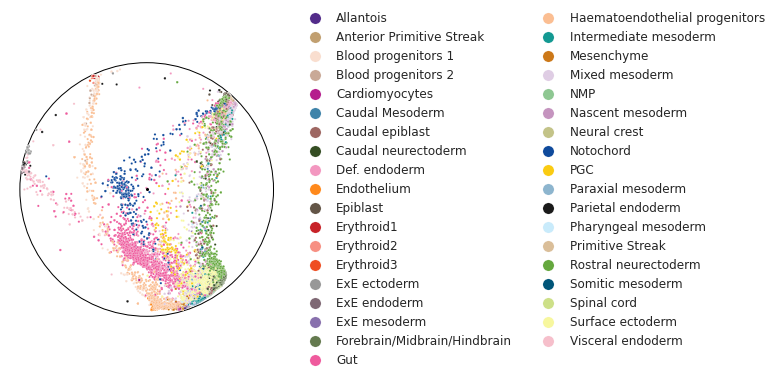

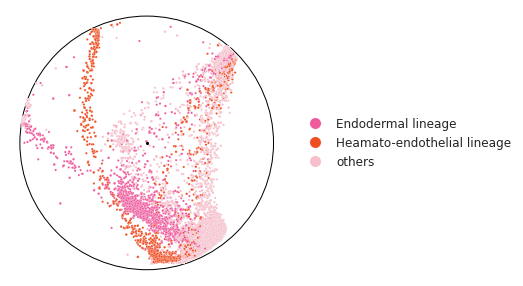

In [5]:
%matplotlib inline

visualise(embedding, target_cells, color_dict_mouse, legend_cols=2)

# Define lineages and visualise 

endoderm_lin = ["Anterior Primitive Streak", "Def. endoderm", "Gut", "Visceral endoderm"]
hem_lin = ["Blood progenitors 1", "Blood progenitors 2", "Erythroid1", "Erythroid2", "Erythroid3",
           "Haematoendothelial progenitors", "Mixed mesoderm"]

df_to_plot = pd.DataFrame()
df_to_plot["target_cells"] = dataset.iloc[idx, -1].values
df_to_plot.loc[~(df_to_plot["target_cells"].isin(endoderm_lin+hem_lin)), "target_cells"] = "others"
df_to_plot.loc[df_to_plot["target_cells"].isin(endoderm_lin), "target_cells"] = "Endodermal lineage"
df_to_plot.loc[df_to_plot["target_cells"].isin(hem_lin), "target_cells"] = "Heamato-endothelial lineage"

target_lin = df_to_plot["target_cells"]


visualise(embedding, target_lin, color_dict_mouse_lineage, legend_cols=1)



Visualization of the embedding following transformation into the Poincaré half-plane enables inference of differentiation origins and rates. The following figure shows the half-plane visualisation of the embedding color coded according their lineages:

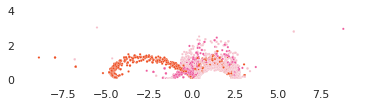

In [6]:
%matplotlib inline
from helpers.visualize import cayley_transform

half_plane_emb = cayley_transform(embedding)

g = sns.scatterplot(x=half_plane_emb[:, 0], y=half_plane_emb[:, 1], hue=target_lin, s=5, 
               palette=color_dict_mouse_lineage, legend=False)
g.set_ylim([0, 4]) #ignore outliers
g.set_aspect("equal")
g.set_facecolor("white")
sns.despine()

One of the strengths of CPM is the resolution of lineages across developmental stages. Here is a visualisation of cell differentiation across nine developmental stages overlaid on the embedding.

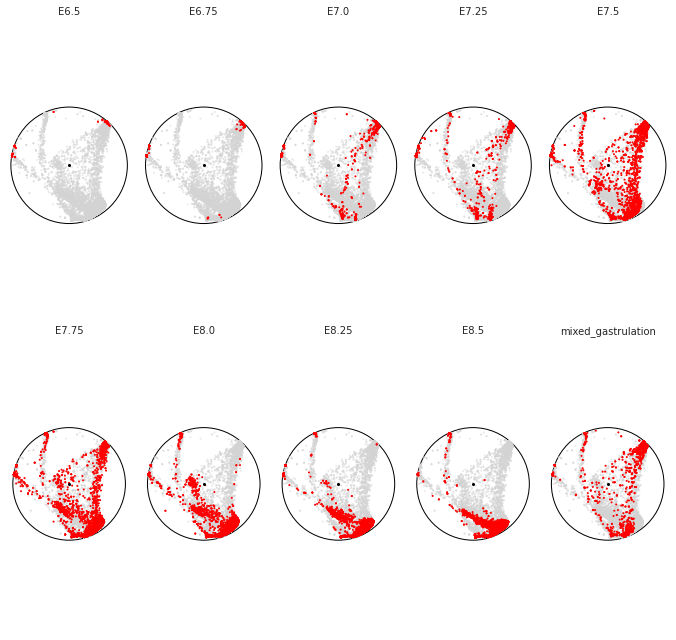

In [7]:
%matplotlib inline

stages = ["E6.5", "E6.75", "E7.0", "E7.25", "E7.5", "E7.75", "E8.0", "E8.25", "E8.5", "mixed_gastrulation"]
target_days = dataset.iloc[idx, -2].values

fig, axes = plt.subplots(
    nrows=2, ncols=5,
    figsize=(9.5, 4.5 * 2))
axes = axes.flatten()

for i, stage in enumerate(stages):
    ax = axes[i]

    # add reference circle
    circle = plt.Circle((0, 0), radius=1, fc='none', color='black')
    ax.add_patch(circle)
    ax.plot(0, 0, '.', c=(0, 0, 0), ms=4)

    sns.scatterplot(x=embedding[:, 0], y=embedding[:, 1],
        color="lightgray", edgecolor="none",
        ax=ax, s=4, alpha=0.5, legend=False)

    # highlight only the cells for this stage in red
    mask = target_days == stage
    sns.scatterplot(x=embedding[mask, 0], y=embedding[mask, 1],
        color="red", edgecolor="none",
        ax=ax, s=4, legend=False)

    ax.set_title(stage, fontsize=10, pad=2)
    ax.axis("off")
    ax.axis("equal")
    fig.tight_layout()

<a id="references"></a>

## References

1. Blanca Pijuan-Sala, Jonathan A Griffiths, Carolina Guibentif, Tom W Hiscock, Wajid Jawaid,
Fernando J Calero-Nieto, Carla Mulas, Ximena Ibarra-Soria, Richard C V Tyser, Debbie
Lee Lian Ho, Wolf Reik, Shankar Srinivas, Benjamin D Simons, Jennifer Nichols, John C
Marioni, and Berthold G¨ottgens. A single-cell molecular map of mouse gastrulation and early
organogenesis. Nature, 566(7745):490–495, 2019.